In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jeanmidev/smart-meters-in-london/darksky_parameters_documentation.html
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/weather_hourly_darksky.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/acorn_details.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/uk_bank_holidays.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/weather_daily_darksky.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/daily_dataset.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/informations_households.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/hhblock_dataset/hhblock_dataset/block_97.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/hhblock_dataset/hhblock_dataset/block_27.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/hhblock_dataset/hhblock_dataset/block_55.csv
/kaggle/input/datasets/jeanmidev/smart-meters-in-london/hhblock_dataset/hhblock_dataset/block_0.csv
/kaggle/input/datasets/jeanmi

In [2]:
# Analyzing the daily_dataset and information_household dataset 
# To balance computational efficiency and representativeness,using a subset of blocks for exploratory analysis and scaled to full data during training

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [4]:
info = pd.read_csv('/kaggle/input/datasets/jeanmidev/smart-meters-in-london/informations_households.csv')

In [5]:
info = info[info['Acorn'] != 'ACORN-']

In [6]:
info['Acorn'].value_counts()

Acorn
ACORN-E    1567
ACORN-Q     831
ACORN-F     684
ACORN-H     455
ACORN-L     342
ACORN-D     292
ACORN-G     205
ACORN-K     165
ACORN-A     157
ACORN-N     152
ACORN-C     151
ACORN-M     113
ACORN-J     112
ACORN-P     110
ACORN-O     103
ACORN-I      51
ACORN-U      49
ACORN-B      25
Name: count, dtype: int64

In [7]:
h1 = info[info['Acorn']=='ACORN-A']['LCLid'].values[0]
h2 = info[info['Acorn']=='ACORN-C']['LCLid'].values[0]
h3 = info[info['Acorn']=='ACORN-E']['LCLid'].values[0]
selected_ids = [h1, h2, h3]

In [8]:
path = '/kaggle/input/datasets/jeanmidev/smart-meters-in-london/daily_dataset/daily_dataset'
files = os.listdir(path)
dfs = []

for file in files:
    if file.endswith('.csv'):
        temp = pd.read_csv(os.path.join(path, file))
        
        filtered = temp[temp['LCLid'].isin(selected_ids)]
        
        if not filtered.empty:
            dfs.append(filtered)

df = pd.concat(dfs, ignore_index=True)

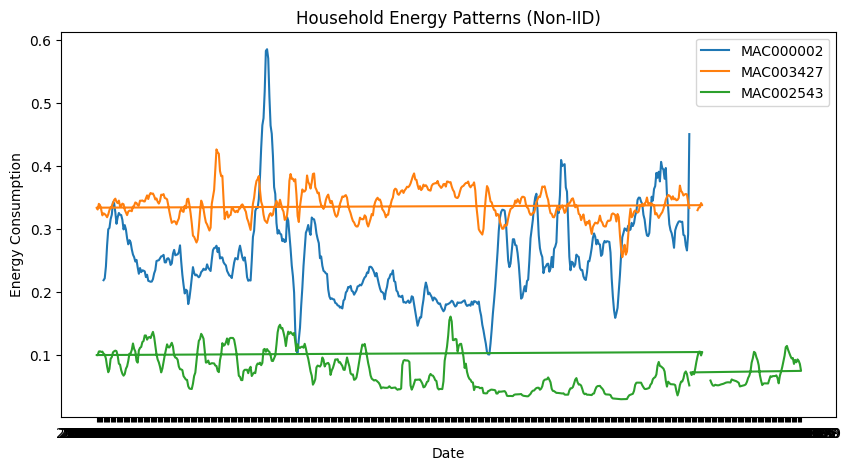

In [9]:
# Different households exhibit significantly different consumption patterns in both magnitude and variability.
# Proves that energy usage is influenced by lifestyle and income
plt.figure(figsize=(10,5))

for hid in selected_ids:
    temp = df[df['LCLid']==hid].sort_values('day')
    
    temp['smooth'] = temp['energy_mean'].rolling(7).mean()
    
    plt.plot(temp['day'], temp['smooth'], label=hid)

plt.legend()
plt.title("Household Energy Patterns (Non-IID)")
plt.xlabel("Date")
plt.ylabel("Energy Consumption")
plt.show()

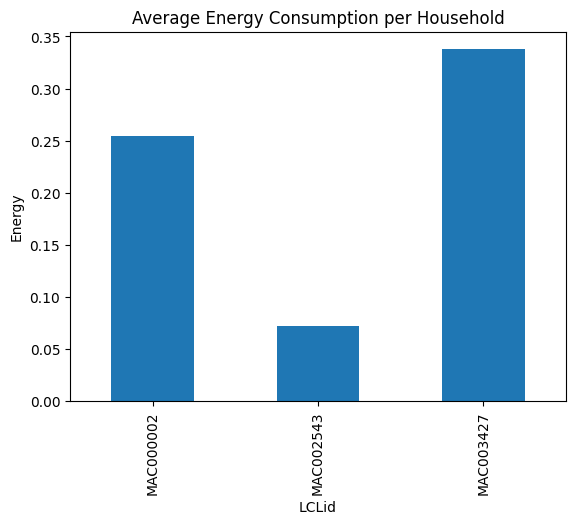

In [10]:
# Energy consumption varies across socio-economic groups, with affluent households consuming more energy.
df.groupby('LCLid')['energy_mean'].mean().plot(kind='bar')
plt.title("Average Energy Consumption per Household")
plt.ylabel("Energy")
plt.show()

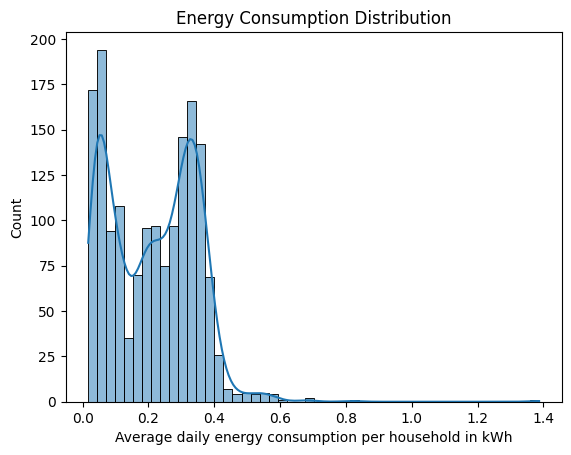

In [11]:
# The distribution is right-skewed, indicating most households consume low energy with occasional high spikes
sns.histplot(df['energy_mean'], bins=50, kde=True)
plt.title("Energy Consumption Distribution")
plt.xlabel("Average daily energy consumption per household in kWh")
plt.show()

In [12]:
# Insights - Multiple peaks suggest multiple different groups exist that align with ACORN categories
#          - Suggests data is not identically distributed
#          - Such skewed distributions can impact model training, so transformations or normalization may be required.

In [13]:
# Due to non-IID and distributed nature of the data, centralized training is suboptimal
# Federated Learning enables training local models on individual households while preserving personalization and privacy

In [14]:
# Loading the Daily Data to get the energy behaviors
print("Loading daily data for ALL households...")
path = '/kaggle/input/datasets/jeanmidev/smart-meters-in-london/daily_dataset/daily_dataset'
files = os.listdir(path)
dfs = []

for file in files:
    if file.endswith('.csv'):
        temp = pd.read_csv(os.path.join(path, file))
        dfs.append(temp)



all_daily_df = pd.concat(dfs, ignore_index=True)


print(f"Total households before filter: {all_daily_df['LCLid'].nunique()}")
household_counts = all_daily_df['LCLid'].value_counts()
valid_households = household_counts[household_counts >= 14].index 


all_daily_df = all_daily_df[all_daily_df['LCLid'].isin(valid_households)]
print(f"Total valid households after filter: {all_daily_df['LCLid'].nunique()}")

Loading daily data for ALL households...
Total households before filter: 5566
Total valid households after filter: 5557


**Execution of K-Means**

In [15]:
# Getting average and max daily energy for every household
# Converting ACORN categories into numeric values, selecting features n scaling them

print("Extracting behavioral features for clustering...")
behavior_df = all_daily_df.groupby('LCLid').agg(
    avg_daily_energy=('energy_sum', 'mean'),
    max_daily_energy=('energy_max', 'max')
).reset_index()


merged_df = pd.merge(behavior_df, info, on='LCLid', how='inner')


le = LabelEncoder()
merged_df['Acorn_Encoded'] = le.fit_transform(merged_df['Acorn'])

# K-Means (k=3)
features_to_cluster = merged_df[['avg_daily_energy', 'max_daily_energy', 'Acorn_Encoded']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_to_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
merged_df['cluster_id'] = kmeans.fit_predict(scaled_features)

print("\nFinal Swarm Distribution:")
print(merged_df['cluster_id'].value_counts())

Extracting behavioral features for clustering...

Final Swarm Distribution:
cluster_id
2    2802
1    1693
0    1060
Name: count, dtype: int64


In [18]:
# Exporting the final mapping 
export_df = merged_df[['LCLid', 'Acorn', 'cluster_id']]
export_df.to_csv("household_cluster_mapping.csv", index=False)
print("\n Saved 'household_cluster_mapping.csv' to Kaggle Output!")


 Saved 'household_cluster_mapping.csv' to Kaggle Output!


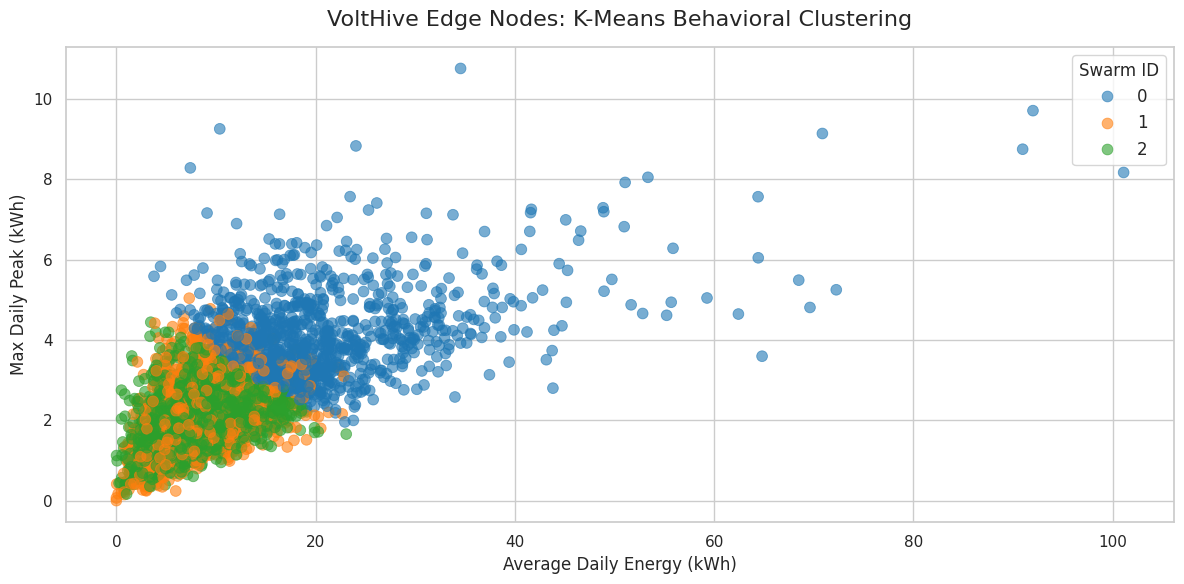

In [20]:
# The Swarm Scatter Plot
# It visualizes the Non-IID (Non-Independent and Identically Distributed) Data Problem
sns.set_theme(style="whitegrid")
palette = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Distinct colors for Swarms 0, 1, 2


plt.figure(figsize=(12, 6))
scatter = sns.scatterplot(
    data=merged_df,
    x='avg_daily_energy',
    y='max_daily_energy',
    hue='cluster_id',
    palette=palette,
    alpha=0.6,
    s=60,
    edgecolor=None
)
plt.title('VoltHive Edge Nodes: K-Means Behavioral Clustering', fontsize=16, pad=15)
plt.xlabel('Average Daily Energy (kWh)', fontsize=12)
plt.ylabel('Max Daily Peak (kWh)', fontsize=12)
plt.legend(title='Swarm ID', fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()
